# advecting_slab_1d

Two things: the error table at the end of the run, and a three-panel
animation of the slab advecting under each method.

`gamma=0` is the null control -- no compression *and* no balancing
diffusion, so the slab just advects. It is there because lowering `gamma`
on a test with no strain does not improve the method, it removes it; the
point of the table is that the psi-normal beats that null rather than
approaching it. See `CDI_METHOD.md` section 5.


In [1]:
import glob, os, sys, logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpi4py import MPI
from pysemtools.io.ppymech.neksuite import preadnek
from pysemtools.datatypes.msh import Mesh as msh_c
from pysemtools.datatypes.field import Field as field_c
from pysemtools.datatypes.coef import Coef

sys.path.insert(0, os.path.abspath(".."))   # examples/norms.py
import norms as nm

logging.disable(logging.INFO)   # pysemtools logs every read
comm = MPI.COMM_WORLD

FPS = 10        # 25 fps ran a full traversal/rotation in under a second

RUNS = [("gamma0_xi10",    r"$\gamma=0$ (CDI off)",      0.01),
        ("gamma025_xi10",  r"$\gamma=0.25$",             0.01),
        ("psi_xi10",       r"$\psi$-normal, no SVV",     0.01),
        ("psi_svvon",      r"$\psi$-normal + SVV",       0.01),
        ("psi_xi28",       r"$\psi$-normal, $\xi=2.8$",  0.028),
        ("psi_xi05",       r"$\psi$-normal, $\xi=0.5$",  0.005),
        ("phi_xi10",       r"$\phi$-normal, $\xi=1.0$",  0.01),
        ("phi_xi05",       r"$\phi$-normal, $\xi=0.5$",  0.005)]

def frames(tag):
    return sorted(glob.glob(f"output_{tag}/field0.f?????"))

## Error and boundedness

The exact solution is evaluated at **the frame's own time**, not at
`end_time`: Neko writes its last frame one step past it, and over a
half-interface-width that is worth a factor of ~5 in $E_r$.

`worst viol` is $\max(\phi-1,\,-\phi,\,0)$ over the whole run rather than
at the last frame -- a run can violate transiently and still end inside
$[0,1]$, which is exactly what the $\phi$-normal does.


In [2]:
msh = coef = None
print(f"{'run':<26} {'t_end':>7} {'E_r':>10} {'E_v':>11} "
      f"{'worst viol':>11} {'worst n':>8}")
for tag, label, eps in RUNS:
    f = frames(tag)
    if not f:
        print(f"{tag:<26}   (no output)"); continue
    if msh is None:
        msh = msh_c(comm, data=preadnek(f[0], comm)); coef = Coef(msh, comm)
    # boundedness over the WHOLE run: a run can violate transiently and
    # still end inside [0,1], so the endpoint alone misleads
    worst_v, worst_n = 0.0, 0
    for ff in f[::10]:
        p = field_c(comm, data=preadnek(ff, comm)).fields["temp"][0]
        worst_v = max(worst_v, max(p.max() - 1.0, -p.min(), 0.0))
        worst_n = max(worst_n, nm.n_unbounded(p))
    phi0 = field_c(comm, data=preadnek(f[0], comm)).fields["temp"][0]
    o = field_c(comm, data=preadnek(f[-1], comm)); phi = o.fields["temp"][0]
    phi_e = nm.slab_phase(msh.x, eps, t=o.t)
    print(f"{tag:<26} {o.t:>7.2f} {nm.E_r(phi, phi_e, coef, msh):>10.5f} "
          f"{nm.E_v(phi, phi0, phi_e, coef, msh):>11.2e} "
          f"{worst_v:>11.2e} {worst_n:>8d}")

# t = 0 self-check: the initial field is the exact solution, so this is 0
p0 = field_c(comm, data=preadnek(frames('psi_xi10')[0], comm)).fields['temp'][0]
print(f"\nt=0 self-check  E_r = {nm.E_r(p0, nm.slab_phase(msh.x, 0.01), coef, msh):.2e}"
      "   (must be 0)")

run                          t_end        E_r         E_v  worst viol  worst n


gamma0_xi10                  20.00    0.01486   -6.98e-12    1.66e-02     5808
gamma025_xi10                20.00    0.00007   -1.59e-11    4.21e-06     2299
psi_xi10                     20.00    0.00006   -4.04e-11    1.90e-07      605
psi_svvon                    20.00    0.00006   -2.86e-11    1.22e-13      121


psi_xi28                     20.00    0.00003   -6.61e-11    0.00e+00        0
psi_xi05                     20.00    0.00044   -3.97e-11    1.26e-03     5445
phi_xi10                     20.00    1.21441    2.92e-01    2.49e-02       64
phi_xi05                      6.80    0.96742   -9.64e-01    3.24e-01     7657

t=0 self-check  E_r = 9.75e-17   (must be 0)


## The slab advecting, one panel per method

$\gamma=0$ against the $\phi$-normal against the $\psi$-normal, the last with
SVV off and on. Four panels, all at $\xi = 1.0$, over twenty flow-throughs.

SVV on $\psi$ uses Saini's own Zalesak setting, $N_{svv} = N/2$ and $c_0 = 1.0$
(their \S4.3), so this panel and `../zalesak_disk` are directly comparable.


In [3]:
EPS = 0.01
PANELS = [("output_gamma0_xi10", r"$\gamma=0$: CDI off"),
          ("output_phi_xi10",    r"$\phi$-normal"),
          ("output_psi_xi10",    r"$\psi$-normal, no SVV"),
          ("output_psi_svvon",   r"$\psi$-normal + SVV")]

def load(d):
    files = sorted(glob.glob(os.path.join(d, "field0.f?????")))
    order = np.argsort(msh.x[:, 0, 0, :].ravel())
    ts, lines, ers = [], [], []
    for f in files:
        o = field_c(comm, data=preadnek(f, comm))
        phi = o.fields["temp"][0]
        ts.append(o.t)
        lines.append(phi[:, 0, 0, :].ravel()[order])
        ers.append(nm.E_r(phi, nm.slab_phase(msh.x, EPS, t=o.t), coef, msh))
    return (msh.x[:, 0, 0, :].ravel()[order], np.array(ts),
            np.array(lines), np.array(ers))

runs = [(lbl,) + load(d) for d, lbl in PANELS]
nf = min(len(r[2]) for r in runs)
print(f"{nf} frames to t = {runs[0][2][nf-1]:.2f}")

402 frames to t = 20.00


In [4]:
def animate(runs, out):
    fig, axes = plt.subplots(1, len(runs), figsize=(4.2*len(runs), 3.6),
                             sharey=True)
    lines, exacts, notes = [], [], []
    for ax, (label, xs, ts, ys, ers) in zip(axes, runs):
        ex, = ax.plot(xs, nm.slab_phase(xs, EPS), color="0.7", lw=1.2, ls="--",
                      label="exact")
        ln, = ax.plot(xs, ys[0], color="C0", lw=1.6, label=r"$\phi$")
        ax.set_ylim(-0.25, 1.25); ax.set_xlim(0, 1); ax.set_xlabel("x")
        ax.axhline(0.0, color="0.85", lw=0.6, zorder=0)
        ax.axhline(1.0, color="0.85", lw=0.6, zorder=0)
        ax.set_title(label, fontsize=11)
        notes.append(ax.text(0.97, 0.95, "", transform=ax.transAxes, fontsize=8.5,
                             family="monospace", va="top", ha="right",
                             bbox=dict(fc="white", ec="0.8", alpha=0.85, pad=2.5)))
        lines.append(ln); exacts.append(ex)
    axes[0].set_ylabel(r"$\phi$"); axes[0].legend(loc="upper left", fontsize=8)
    sup = fig.suptitle("")
    fig.tight_layout(rect=(0, 0, 1, 0.93))

    def frame(i):
        t = runs[0][2][i]
        ex = nm.slab_phase(runs[0][1], EPS, t=t)
        for ln, exl, note, (label, xs, ts, ys, ers) in zip(lines, exacts, notes, runs):
            ln.set_ydata(ys[i]); exl.set_ydata(ex)
            note.set_text(f"$E_r$ = {ers[i]:7.4f}\n"
                          f"$\\phi\\in$[{ys[i].min():+.3f}, {ys[i].max():+.3f}]")
        sup.set_text(f"1D advecting slab, $\\xi = 1.0$      "
                     f"t = {t:5.2f}  ({t:.1f} flow-throughs of 20)")
        return lines + exacts + notes + [sup]

    FuncAnimation(fig, frame, frames=nf, blit=False).save(
        out, writer=FFMpegWriter(fps=FPS, bitrate=2400))
    plt.close(fig)
    print("wrote", out)

os.makedirs("evidence", exist_ok=True)
animate(runs, "evidence/slab_1d_methods.mp4")
animate(runs[:2], "evidence/slab_1d_cdi_off_vs_phi.mp4")

wrote evidence/slab_1d_methods.mp4


wrote evidence/slab_1d_cdi_off_vs_phi.mp4


## Why this case needs no redistancing, measured

Redistancing exists to restore $|\nabla\psi| = 1$ after strain drives it away.
This case has $\mathbf{u} = $ const, so $\nabla\mathbf{u} = 0$ and
$D|\nabla\psi|/Dt = -|\nabla\psi|(\mathbf{n}\cdot\nabla\mathbf{u}\cdot\mathbf{n}) = 0$
**exactly** — there is no physical drift to correct.

What is left is discretisation error, and the plot below shows it is not small:
the band minimum dips to $\sim0.04$ and the maximum reaches $\sim2.3$. Yet this
run has $E_r = 0.00006$ and a worst boundedness violation of $1.9\times10^{-7}$.

That is the point: **$|\nabla\psi|$ excursions of this size are harmless**, because
the normal $\nabla\psi/|\nabla\psi|$ is invariant under any monotone
reparametrisation of $\psi$ — it depends on the level sets, not the gradient
magnitude. A trigger watching $|\nabla\psi|$ against a tolerance band around 1
would fire repeatedly here and redistance a solution that is already correct.
See `REDISTANCING.md`.


|grad psi| over the band: min 0.0006, max 3.6049 (a 5686x spread)
band mean stays in [0.9311, 1.0925] -- never leaves the trigger band,
so the solver would not have fired; a min-based trigger would have fired constantly.
Either way E_r = 0.00006 and the worst boundedness violation is 1.9e-07.


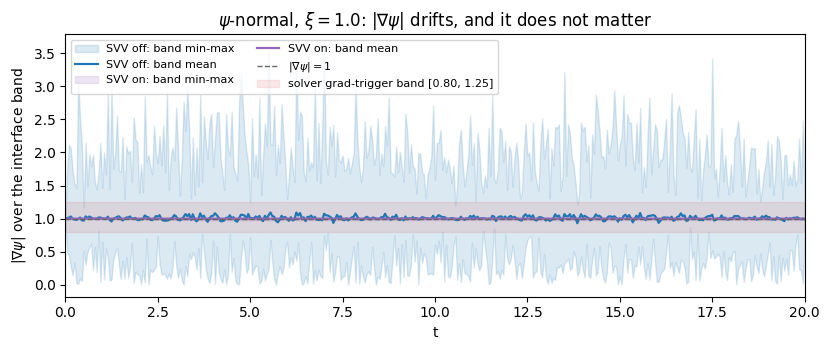

In [5]:
gpsi = {}
for tag, label, _ in [r for r in RUNS if r[0] in ('psi_xi10', 'psi_svvon')]:
    f = frames(tag)
    ts, mn, me, mx = [], [], [], []
    for ff in f:
        o = field_c(comm, data=preadnek(ff, comm))
        phi, psi = o.fields['temp'][0], o.fields['scal'][0]
        g = np.abs(coef.dudxyz(psi, coef.drdx, coef.dsdx, coef.dtdx))
        b = phi*(1.0 - phi) > 1e-4      # the project's interface-band convention
        ts.append(o.t); mn.append(g[b].min()); me.append(g[b].mean()); mx.append(g[b].max())
    gpsi[tag] = (np.array(ts), np.array(mn), np.array(me), np.array(mx))

fig, ax = plt.subplots(figsize=(8.4, 3.6))
for tag, lbl, col in (('psi_xi10', 'SVV off', 'C0'), ('psi_svvon', 'SVV on', 'C4')):
    if tag not in gpsi:
        continue
    ts, mn, me, mx = gpsi[tag]
    ax.fill_between(ts, mn, mx, color=col, alpha=0.16,
                    label=f'{lbl}: band min-max')
    ax.plot(ts, me, color=col, lw=1.6, label=f'{lbl}: band mean')
ts, mn, me, mx = gpsi['psi_xi10']
ax.axhline(1.0, color='0.4', lw=1.0, ls='--', label=r'$|\nabla\psi|=1$')
ax.axhspan(0.80, 1.25, color='C3', alpha=0.10,
           label='solver grad-trigger band [0.80, 1.25]')
ax.set_xlabel('t'); ax.set_ylabel(r'$|\nabla\psi|$ over the interface band')
ax.set_title(r'$\psi$-normal, $\xi=1.0$: $|\nabla\psi|$ drifts, and it does not matter')
ax.legend(fontsize=8, loc='upper left', ncol=2); ax.set_xlim(0, ts[-1])
fig.tight_layout(); fig.savefig('evidence/slab_1d_grad_psi.png', dpi=140)

print(f'|grad psi| over the band: min {mn.min():.4f}, max {mx.max():.4f} '
      f'(a {mx.max()/mn.min():.0f}x spread)')
print(f'band mean stays in [{me.min():.4f}, {me.max():.4f}] -- never leaves the trigger band,')
print('so the solver would not have fired; a min-based trigger would have fired constantly.')
print('Either way E_r = 0.00006 and the worst boundedness violation is 1.9e-07.')

## What $\psi$ itself looks like, with SVV off and on

$\phi$, $\psi$, and $\psi$'s error, with the interface band shaded — the band is
the only place $\psi$ can reach $\phi$, because the compression flux
$-\phi(1-\phi)\mathbf{n}$ vanishes outside it.

Both SVV states are overlaid. In 1D uniform advection $|\nabla\psi|$ is
*provably* conserved, so any drift is pure discretisation error and SVV has
little to correct — which is the point of showing it here rather than assuming
it. SVV uses Saini's \S4.3 setting, $N_{svv}=N/2$, $c_0=1.0$.


In [6]:
order = np.argsort(msh.x[:, 0, 0, :].ravel())
xs = msh.x[:, 0, 0, :].ravel()[order]

SVV_RUNS = [("psi_xi10",  "SVV off", "C1"),
            ("psi_svvon", "SVV on",  "C4")]

def load_psi(tag):
    ts, phis, psis, bands, gmm = [], [], [], [], []
    for f in frames(tag):
        o = field_c(comm, data=preadnek(f, comm))
        ph, ps = o.fields["temp"][0], o.fields["scal"][0]
        g = np.abs(coef.dudxyz(ps, coef.drdx, coef.dsdx, coef.dtdx))
        b = ph*(1.0 - ph) > 1e-4          # where the compression flux is non-zero
        ts.append(o.t); phis.append(ph[:, 0, 0, :].ravel()[order])
        psis.append(ps[:, 0, 0, :].ravel()[order])
        bands.append(b[:, 0, 0, :].ravel()[order])
        gmm.append((g[b].min(), g[b].max()))
    return dict(t=np.array(ts), phi=np.array(phis), psi=np.array(psis),
                band=np.array(bands), gmm=np.array(gmm))

D = {tag: load_psi(tag) for tag, _, _ in SVV_RUNS}
ts = D[SVV_RUNS[0][0]]["t"]
nf2 = min(len(D[t]["t"]) for t, _, _ in SVV_RUNS)
bands = D[SVV_RUNS[0][0]]["band"]        # phi is near-identical; shade once

# the band phi(1-phi) > 1e-4 is |psi| < ~9.2*eps: outside it the compression
# flux -phi(1-phi)*n vanishes, so psi's shape there cannot reach phi at all
PLIM, RLIM = (-0.36, 0.26), 6e-3
fig, (axp, axs, axr) = plt.subplots(1, 3, figsize=(15.4, 3.9))
exp_, = axp.plot(xs, nm.slab_phase(xs, EPS), "--", color="0.7", lw=1.2, label="exact")
exs_, = axs.plot(xs, nm.slab_distance(xs), "--", color="0.7", lw=1.2, label="exact")
lp, ls_, lr = {}, {}, {}
for tag, lbl, col in SVV_RUNS:
    lp[tag],  = axp.plot(xs, D[tag]["phi"][0], color=col, lw=1.5, label=lbl)
    ls_[tag], = axs.plot(xs, D[tag]["psi"][0], color=col, lw=1.5, label=lbl)
    lr[tag],  = axr.plot(xs, D[tag]["psi"][0] - nm.slab_distance(xs),
                         color=col, lw=1.3, label=lbl)
axp.set_ylim(-0.25, 1.25); axp.set_xlim(0, 1); axp.set_xlabel("x")
axp.set_ylabel(r"$\phi$"); axp.set_title(r"$\phi$ — the phase field")
axs.set_ylim(*PLIM); axs.set_xlim(0, 1); axs.set_xlabel("x")
axs.set_ylabel(r"$\psi$"); axs.set_title(r"$\psi$ — the transported distance")
axs.axhline(0.0, color="0.85", lw=0.6, zorder=0)
# psi's error is ~1e-3 on a field of range 0.5 -- invisible at field scale, so
# show it directly. This is the panel that actually says where psi degrades.
axr.set_ylim(-RLIM, RLIM); axr.set_xlim(0, 1); axr.set_xlabel("x")
axr.set_ylabel(r"$\psi - \psi_{\rm exact}$")
axr.set_title(r"$\psi$ error ($\times$500 the scale at left)")
axr.axhline(0.0, color="0.85", lw=0.6, zorder=0)
note = axs.text(0.97, 0.05, "", transform=axs.transAxes, fontsize=8,
                family="monospace", ha="right", va="bottom",
                bbox=dict(fc="white", ec="0.8", alpha=0.9, pad=2.5))
shade = [None, None, None]
sup = fig.suptitle(""); fig.tight_layout(rect=(0, 0, 1, 0.90))

def frame2(i):
    exp_.set_ydata(nm.slab_phase(xs, EPS, t=ts[i]))
    exs_.set_ydata(nm.slab_distance(xs, t=ts[i]))
    ex = nm.slab_distance(xs, t=ts[i])
    for tag, _, _ in SVV_RUNS:
        lp[tag].set_ydata(D[tag]["phi"][i])
        ls_[tag].set_ydata(D[tag]["psi"][i])
        lr[tag].set_ydata(D[tag]["psi"][i] - ex)
    for k, (ax, lim) in enumerate(((axp, (-0.25, 1.25)), (axs, PLIM),
                                   (axr, (-RLIM, RLIM)))):
        if shade[k] is not None:
            shade[k].remove()
        shade[k] = ax.fill_between(xs, lim[0], lim[1], where=bands[i],
                                   color="C2", alpha=0.13, lw=0, zorder=0,
                                   label="interface band" if i == 0 else None)
    note.set_text("in band  $|\\nabla\\psi|$ min/max\n" + "\n".join(
        f"{lbl:<7} {D[tag]['gmm'][i,0]:.3f} / {D[tag]['gmm'][i,1]:.2f}"
        for tag, lbl, _ in SVV_RUNS))
    sup.set_text(f"$\\psi$-normal, $\\xi=1.0$    t = {ts[i]:5.2f}    "
                 f"shaded = interface band, the only place $\\psi$ can affect $\\phi$")
    return ([exp_, exs_, note, sup] + list(lp.values()) + list(ls_.values())
            + list(lr.values()) + [s for s in shade if s is not None])

frame2(0)
axp.legend(loc="upper left", fontsize=8); axs.legend(loc="upper left", fontsize=8)
out2 = "evidence/slab_1d_psi_field.mp4"
FuncAnimation(fig, frame2, frames=nf2, blit=False).save(
    out2, writer=FFMpegWriter(fps=FPS, bitrate=2400))
plt.close(fig)
print("wrote", out2)
for tag, lbl, _ in SVV_RUNS:
    d = D[tag]; inb = d["band"][-1]; ex = nm.slab_distance(xs, t=d["t"][-1])
    print(f"{lbl:>8}: max |psi-exact| in band {np.abs(d['psi'][-1]-ex)[inb].max():.5f}"
          f"   outside {np.abs(d['psi'][-1]-ex)[~inb].max():.5f}"
          f"   band |grad psi| {d['gmm'][-1,0]:.4f}..{d['gmm'][-1,1]:.2f}")


wrote evidence/slab_1d_psi_field.mp4
 SVV off: max |psi-exact| in band 0.00104   outside 0.00455   band |grad psi| 0.6256..1.33
  SVV on: max |psi-exact| in band 0.00024   outside 0.00673   band |grad psi| 0.9828..1.01


## Redistancing: what it costs to give up the analytic distance

The other cases seed $\psi$ from a closed-form signed distance. Real geometries
have none, so the configuration that matters is $\psi$ **built** from $\phi$ by
Saini Eq. (44) — `psi_init = "redistance"`. This is the cheapest place in the
repo to measure what that costs and whether periodic redistancing pays it back.


In [7]:
# The pseudo-timestep is varied INSIDE the build as well as inside the events,
# so both must be held fixed to attribute anything: "coarse" is Saini's
# dtau = H/(N+1) (pseudo-CFL 2.755), "fine" is cfl = 0.1.
RD_RUNS = [("psi_xi10",        "analytic $\\psi$",                 "C0"),
           ("psi_rd_off_cfl",  "built (fine), no redist.",         "C2"),
           ("psi_rd_on_cfl",   "built (fine) + redist.",           "C9"),
           ("psi_rd_off",      "built (coarse), no redist.",       "C3"),
           ("psi_rd_on",       "built (coarse) + redist.",         "C1")]

R = {}
for tag, lbl, col in RD_RUNS:
    ff = frames(tag)
    if not ff:
        print(f"  (skip {tag})"); continue
    ts, er, gmean, psilast = [], [], [], None
    for f in ff:
        o = field_c(comm, data=preadnek(f, comm))
        ph, ps = o.fields["temp"][0], o.fields["scal"][0]
        g = np.abs(coef.dudxyz(ps, coef.drdx, coef.dsdx, coef.dtdx))
        b = ph*(1.0 - ph) > 1e-4
        ts.append(o.t); er.append(nm.E_r(ph, nm.slab_phase(msh.x, EPS, t=o.t), coef, msh))
        gmean.append(g[b].mean() if b.any() else np.nan)
        psilast = ps[:, 0, 0, :].ravel()[order]
    R[tag] = dict(t=np.array(ts), Er=np.array(er), g=np.array(gmean), psi=psilast)

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(15.4, 4.0))
a0.plot(xs, nm.slab_distance(xs, t=R[RD_RUNS[0][0]]["t"][-1]), "--", color="0.6",
        lw=1.3, label="exact distance")
for tag, lbl, col in RD_RUNS:
    if tag not in R: continue
    a0.plot(xs, R[tag]["psi"], color=col, lw=1.4, label=lbl)
    a1.plot(R[tag]["t"], np.maximum(R[tag]["Er"], 1e-6), color=col, lw=1.4, label=lbl)
    a2.plot(R[tag]["t"], R[tag]["g"], color=col, lw=1.4, label=lbl)
a0.set_xlabel("x"); a0.set_ylabel(r"$\psi$"); a0.set_xlim(0, 1)
# the H/(N+1) run reaches ~1e22; clip to the physical range so the other three
# stay readable and the blown-up one simply leaves the frame
a0.set_ylim(-0.36, 0.28)
a0.set_title(r"$\psi$ at $t=20$"); a0.legend(fontsize=7.5); a0.grid(alpha=0.3)
a1.set_yscale("log"); a1.set_xlabel("t"); a1.set_ylabel(r"$E_r$")
a1.set_title(r"$E_r$ — build resolution decides"); a1.grid(alpha=0.3, which="both")
a2.set_yscale("log"); a2.set_xlabel("t")
a2.set_ylabel(r"band mean $|\nabla\psi|$")
a2.axhline(1.0, color="k", lw=0.7, ls=":")
a2.set_title(r"band $|\nabla\psi|$ — why the coarse $\Delta\tau$ fails")
a2.grid(alpha=0.3, which="both")
fig.suptitle("1D slab, $\\xi=1$, $\\gamma=1$, SVV on, 20 flow-throughs. "
             "A $\\psi$ BUILT from $\\phi$ by Eq. (44) matches the analytic "
             "distance exactly ($E_r$ 0.00006 both) - no closed form needed.\n"
             "The pseudo-timestep is the only thing that matters: at Saini's "
             "$\\Delta\\tau=H/(N{+}1)$ (pseudo-CFL 2.755) the build is already "
             "wrong, and 40 events drive $|\\nabla\\psi|$ to $10^{30}$.",
             fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.88))
fig.savefig("evidence/slab_1d_redistancing.png", dpi=160)
plt.close(fig)
print("wrote evidence/slab_1d_redistancing.png")
for tag, lbl, _ in RD_RUNS:
    if tag in R:
        print(f"  {lbl:<34} E_r(20) = {R[tag]['Er'][-1]:.5f}   "
              f"band |grad psi| {R[tag]['g'][-1]:.4g}")


wrote evidence/slab_1d_redistancing.png
  analytic $\psi$                    E_r(20) = 0.00006   band |grad psi| 0.9941
  built (fine), no redist.           E_r(20) = 0.00006   band |grad psi| 0.9992
  built (fine) + redist.             E_r(20) = 0.00023   band |grad psi| 1
  built (coarse), no redist.         E_r(20) = 0.06458   band |grad psi| 1.034
  built (coarse) + redist.           E_r(20) = 1.18822   band |grad psi| 1.237e+23


In [8]:
from IPython.display import Video
Video("evidence/slab_1d_methods.mp4", embed=False, width=980)